# Inmate Anomaly Detection — Pipeline Showcase
## Violence Prediction via Computer Vision in Nigerian Correctional Facilities

This notebook demonstrates the full preprocessing, analysis, and anomaly scoring pipeline
using the **UCF-Crime**, **Avenue**, and **ShanghaiTech** datasets.

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print(f'Project root: {PROJECT_ROOT}')

Project root: e:\Data


In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict, Counter
from pathlib import Path

from inmate_anomaly_detection.preprocessing import (
    load_image, preprocess_frame, get_transforms,
    discover_frame_paths, group_frames_by_video_prefix,
    group_into_clips
)
from inmate_anomaly_detection.analysis import (
    compute_anomaly_score, compute_motion_energy,
    compute_motion_entropy, analyze_batch
)
from inmate_anomaly_detection.dataloader import build_loaders
from inmate_anomaly_detection.model import (
    ResNet18Encoder, LSTMAutoencoder, SpatiotemporalModel, count_parameters
)
from inmate_anomaly_detection.train_utils import load_checkpoint
from inmate_anomaly_detection.config import (
    CLIP_LENGTH, STRIDE, FRAME_SIZE, IMAGENET_MEAN, IMAGENET_STD,
    CNN_FEATURE_DIM, LSTM_HIDDEN, LSTM_LAYERS, LSTM_DROPOUT,
    FREEZE_BACKBONE, UNFREEZE_LAYERS, CHECKPOINT_DIR,
    ANOMALY_PERCENTILE, BATCH_SIZE,
)

sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'
%matplotlib inline

---
## 1. Dataset Overview

Three public anomaly-detection datasets are used. UCF-Crime provides the broadest coverage
with 14 categories including both normal and anomalous activities.

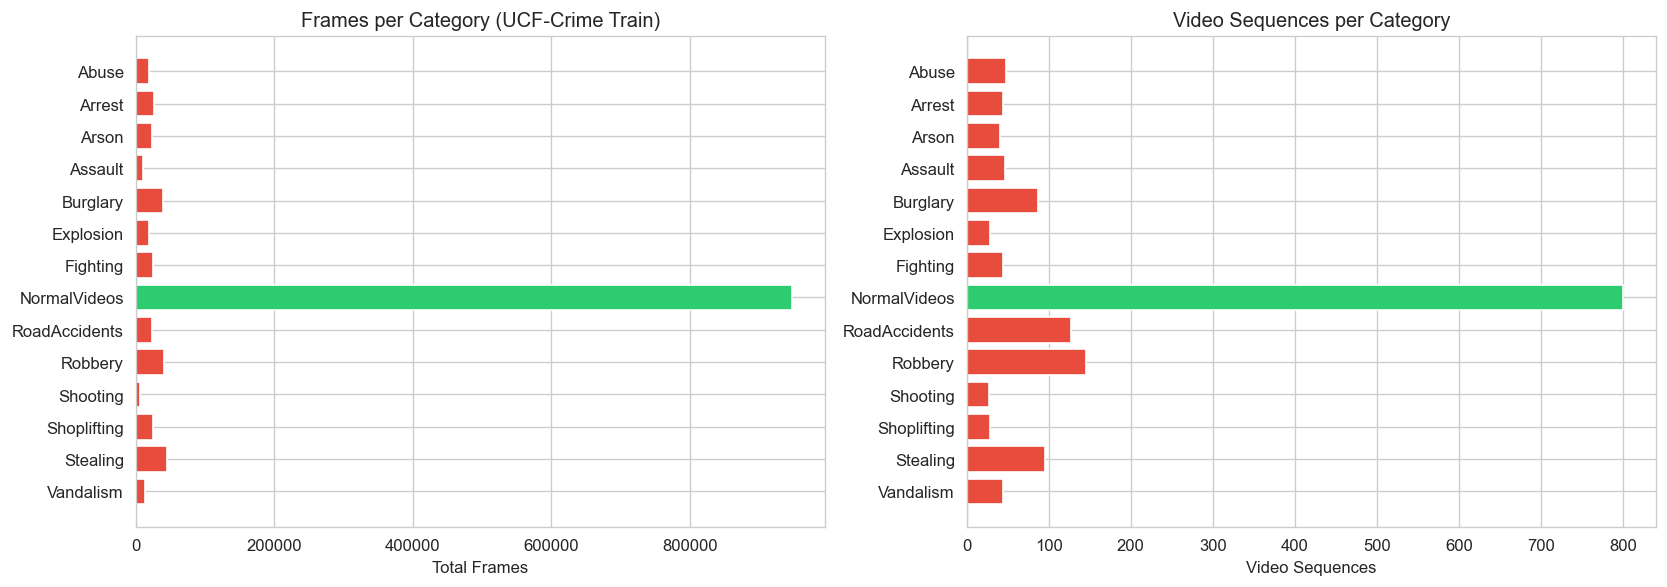

In [5]:
TRAIN = PROJECT_ROOT / "dataset" / "archive (1)" / "Train"

categories = {}
for cat_dir in sorted(TRAIN.iterdir()):
    if cat_dir.is_dir():
        frames = discover_frame_paths(cat_dir)
        groups = group_frames_by_video_prefix(frames)
        categories[cat_dir.name] = {"total_frames": len(frames), "videos": len(groups)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(categories.keys())
frames_list = [categories[n]["total_frames"] for n in names]
videos_list = [categories[n]["videos"] for n in names]

colors = ['#e74c3c' if n != 'NormalVideos' else '#2ecc71' for n in names]

axes[0].barh(names, frames_list, color=colors)
axes[0].set_xlabel("Total Frames")
axes[0].set_title("Frames per Category (UCF-Crime Train)")
axes[0].invert_yaxis()

axes[1].barh(names, videos_list, color=colors)
axes[1].set_xlabel("Video Sequences")
axes[1].set_title("Video Sequences per Category")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

---
## 2. Preprocessing Pipeline

Each frame goes through:
1. **Resize** → 224×224 pixels (standard CNN input size)
2. **BGR → RGB** color conversion (OpenCV loads as BGR)
3. **Normalize** with ImageNet μ=[0.485,0.456,0.406], σ=[0.229,0.224,0.225]
4. **Clip grouping** → 16 consecutive frames per clip, stride of 8

In [6]:
transform = get_transforms(augment=False)

fighting_dir = TRAIN / "Fighting"
all_frames = discover_frame_paths(fighting_dir)
groups = group_frames_by_video_prefix(all_frames)

first_video = sorted(groups.keys())[0]
frame_paths = sorted(groups[first_video])[:80]

print(f"Video: {first_video}")
print(f"Sample frames: {len(frame_paths)}")
print(f"Output clips (CLIP_LENGTH={CLIP_LENGTH}, STRIDE={STRIDE}): {(len(frame_paths) - CLIP_LENGTH) // STRIDE + 1}")
print(f"Output tensor shape per clip: ({CLIP_LENGTH}, 3, {FRAME_SIZE}, {FRAME_SIZE})")

Video: Fighting002_x264
Sample frames: 80
Output clips (CLIP_LENGTH=16, STRIDE=8): 9
Output tensor shape per clip: (16, 3, 224, 224)


### 2.1 Raw vs. Preprocessed Frame Comparison

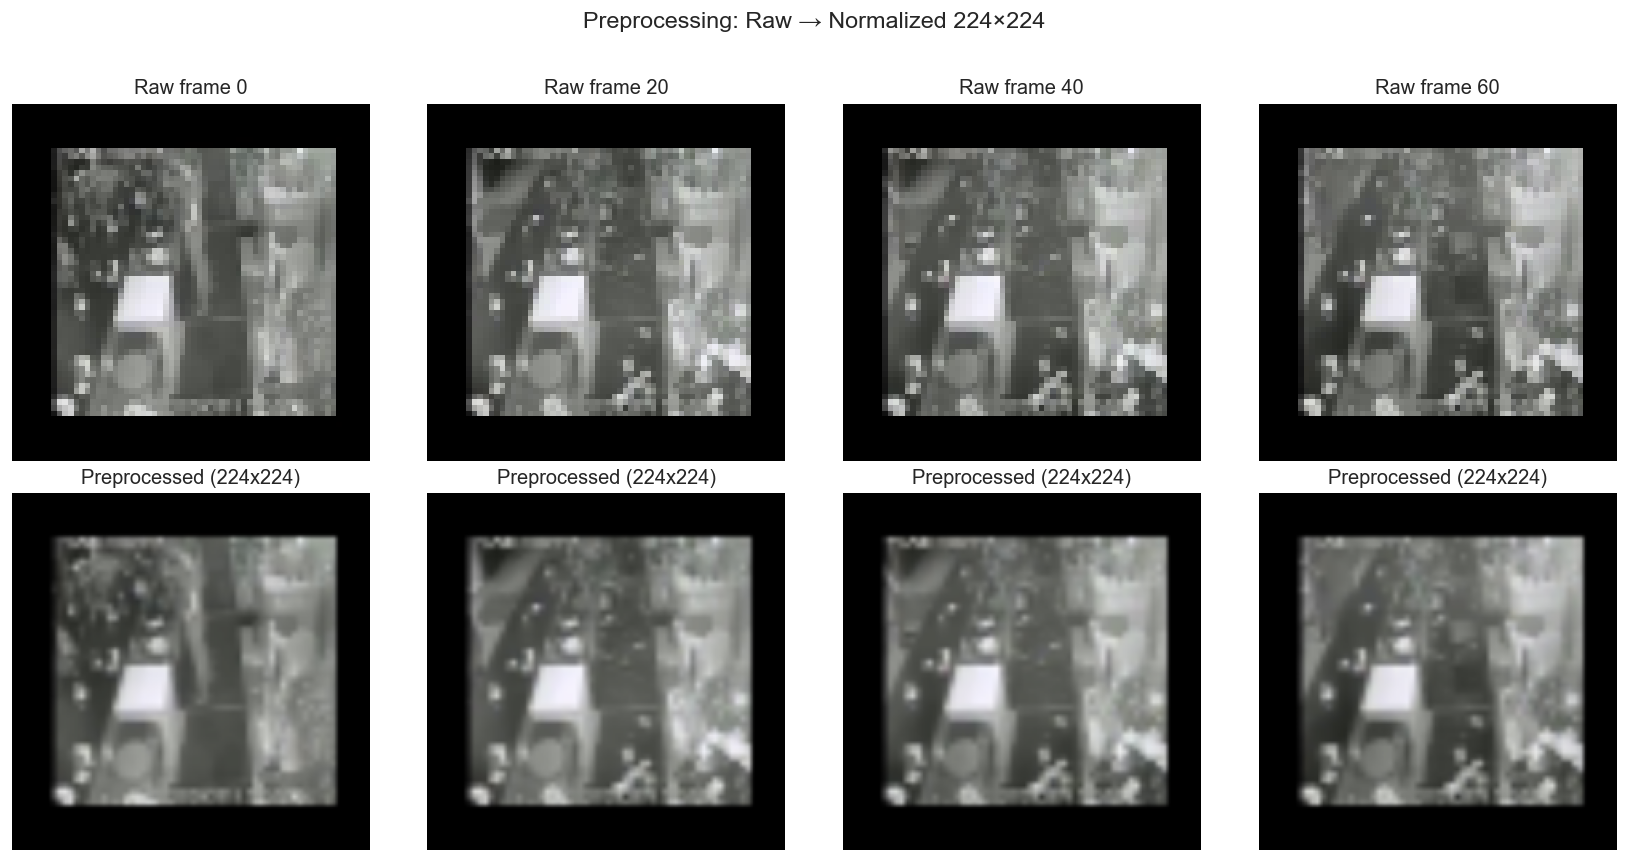

In [7]:
indices = [0, 20, 40, 60]

fig, axes = plt.subplots(2, len(indices), figsize=(14, 7))

for i, idx in enumerate(indices):
    raw = load_image(frame_paths[idx])
    processed = preprocess_frame(raw, transform)

    # Denormalize for display
    display = processed.numpy().copy()
    for c in range(3):
        display[c] = display[c] * IMAGENET_STD[c] + IMAGENET_MEAN[c]
    display = np.clip(display.transpose(1, 2, 0), 0, 1)

    axes[0, i].imshow(raw)
    axes[0, i].set_title(f"Raw frame {idx}")
    axes[0, i].axis('off')

    axes[1, i].imshow(display)
    axes[1, i].set_title(f"Preprocessed (224x224)")
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Raw (original)", fontsize=12)
axes[1, 0].set_ylabel("Preprocessed", fontsize=12)
plt.suptitle("Preprocessing: Raw → Normalized 224×224", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.2 Clip Structure Visualization

16 consecutive frames are stacked into a single clip. The stride of 8 means
adjacent clips overlap by 8 frames, capturing smooth behavioral transitions.

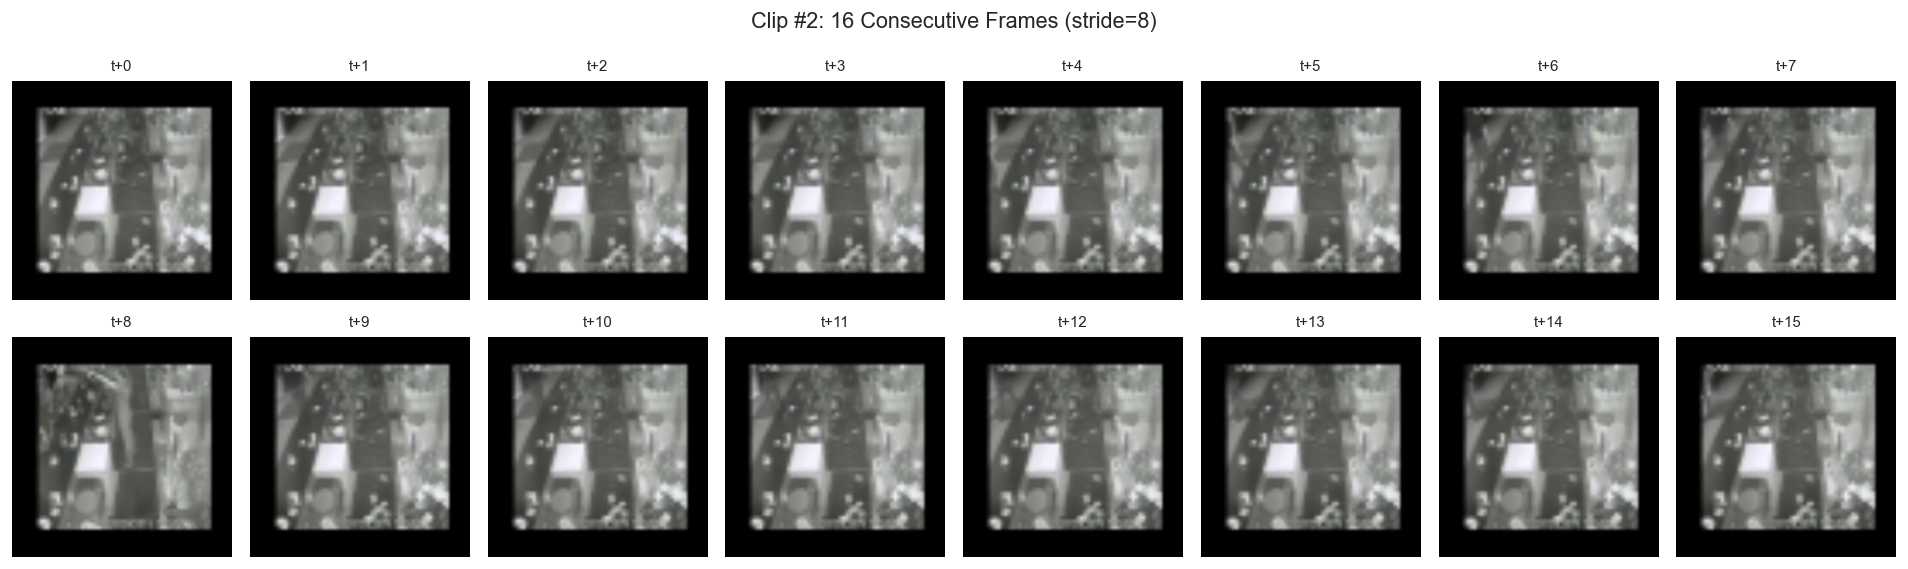

In [8]:
tensors = [preprocess_frame(load_image(p), transform) for p in frame_paths]
clips = group_into_clips(tensors, CLIP_LENGTH, STRIDE)

clip_idx = 2
clip = clips[clip_idx]

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle(f"Clip #{clip_idx}: 16 Consecutive Frames (stride={STRIDE})", fontsize=13)

for i in range(16):
    ax = axes[i // 8, i % 8]
    frame = clip[i].numpy().copy()
    for c in range(3):
        frame[c] = frame[c] * IMAGENET_STD[c] + IMAGENET_MEAN[c]
    frame = np.clip(frame.transpose(1, 2, 0), 0, 1)
    ax.imshow(frame)
    ax.set_title(f"t+{i}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 3. Anomaly Detection via Motion Analysis

Before training the ResNet+LSTM model, we perform a **simple but informative baseline**
using **frame-to-frame differencing**. The intuition:

- **Normal behavior**: predictable, low-motion, structured movement
- **Violent behavior**: rapid, chaotic, high-energy motion patterns

We compute two metrics:
1. **Motion Energy** — mean absolute pixel difference between consecutive frames
2. **Motion Entropy** — Shannon entropy of the difference histogram (measures chaos)

Combined anomaly score: `0.4 × energy + 0.6 × entropy`

In [9]:
# Load one clip from NormalVideos and one from Fighting for comparison
normal_dir = TRAIN / "NormalVideos"
normal_frames = discover_frame_paths(normal_dir)
normal_groups = group_frames_by_video_prefix(normal_frames)

def get_first_clip(category_dir, max_f=80):
    frames = discover_frame_paths(category_dir)
    groups = group_frames_by_video_prefix(frames)
    for prefix in sorted(groups.keys()):
        paths = sorted(groups[prefix])[:max_f]
        if len(paths) >= CLIP_LENGTH:
            tensors = [preprocess_frame(load_image(p), transform) for p in paths]
            clips = group_into_clips(tensors, CLIP_LENGTH, STRIDE)
            if clips:
                return clips[0], prefix
    return None, None

normal_clip, _ = get_first_clip(normal_dir)
fighting_clip, _ = get_first_clip(fighting_dir, 200)
burglary_clip, _ = get_first_clip(TRAIN / "Burglary", 200)
explosion_clip, _ = get_first_clip(TRAIN / "Explosion", 200)

print(f"Clip shapes — Normal: {normal_clip.shape}, Fighting: {fighting_clip.shape}, "
      f"Burglary: {burglary_clip.shape}, Explosion: {explosion_clip.shape}")

Clip shapes — Normal: torch.Size([16, 3, 224, 224]), Fighting: torch.Size([16, 3, 224, 224]), Burglary: torch.Size([16, 3, 224, 224]), Explosion: torch.Size([16, 3, 224, 224])


### 3.1 Frame Difference Heatmaps

Brighter pixels = more motion between consecutive frames. Anomalous clips show
denser and more intense difference patterns.

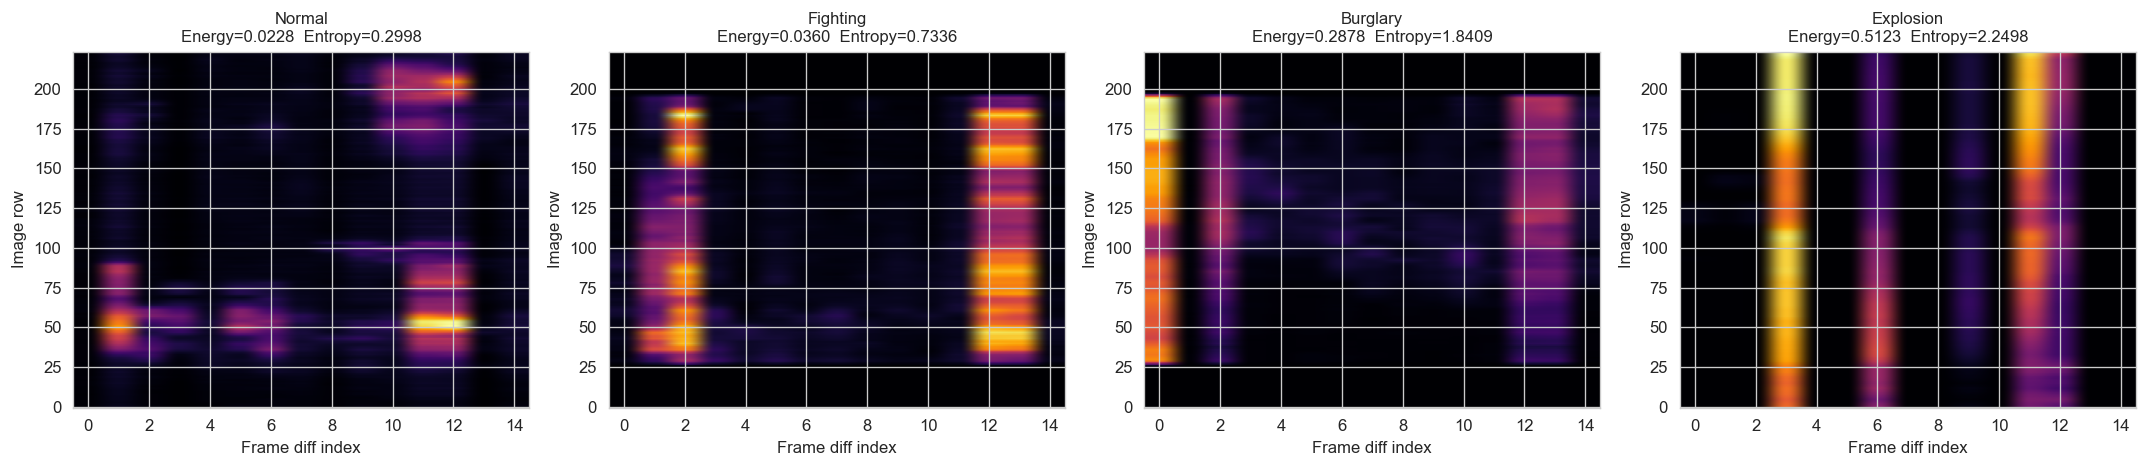

In [10]:
from inmate_anomaly_detection.analysis import compute_frame_differences

def show_diff_heatmaps(clip, title, ax):
    diffs = compute_frame_differences(clip)  # shape: (T-1, H, W)
    collapsed = diffs.mean(axis=-1)  # (T-1, H) — mean across width for each row
    im = ax.imshow(collapsed.T, aspect='auto', cmap='inferno', origin='lower')
    ax.set_xlabel("Frame diff index")
    ax.set_ylabel("Image row")
    ax.set_title(f"{title}\nEnergy={compute_motion_energy(clip):.4f}  Entropy={compute_motion_entropy(clip):.4f}", fontsize=10)
    return im

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for clip, name, ax in zip(
    [normal_clip, fighting_clip, burglary_clip, explosion_clip],
    ["Normal", "Fighting", "Burglary", "Explosion"],
    axes
):
    show_diff_heatmaps(clip, name, ax)

plt.tight_layout()
plt.show()

### 3.2 Motion Energy & Entropy per Frame Pair

Plotting energy and entropy for each consecutive frame pair within a clip
reveals the temporal dynamics of motion.

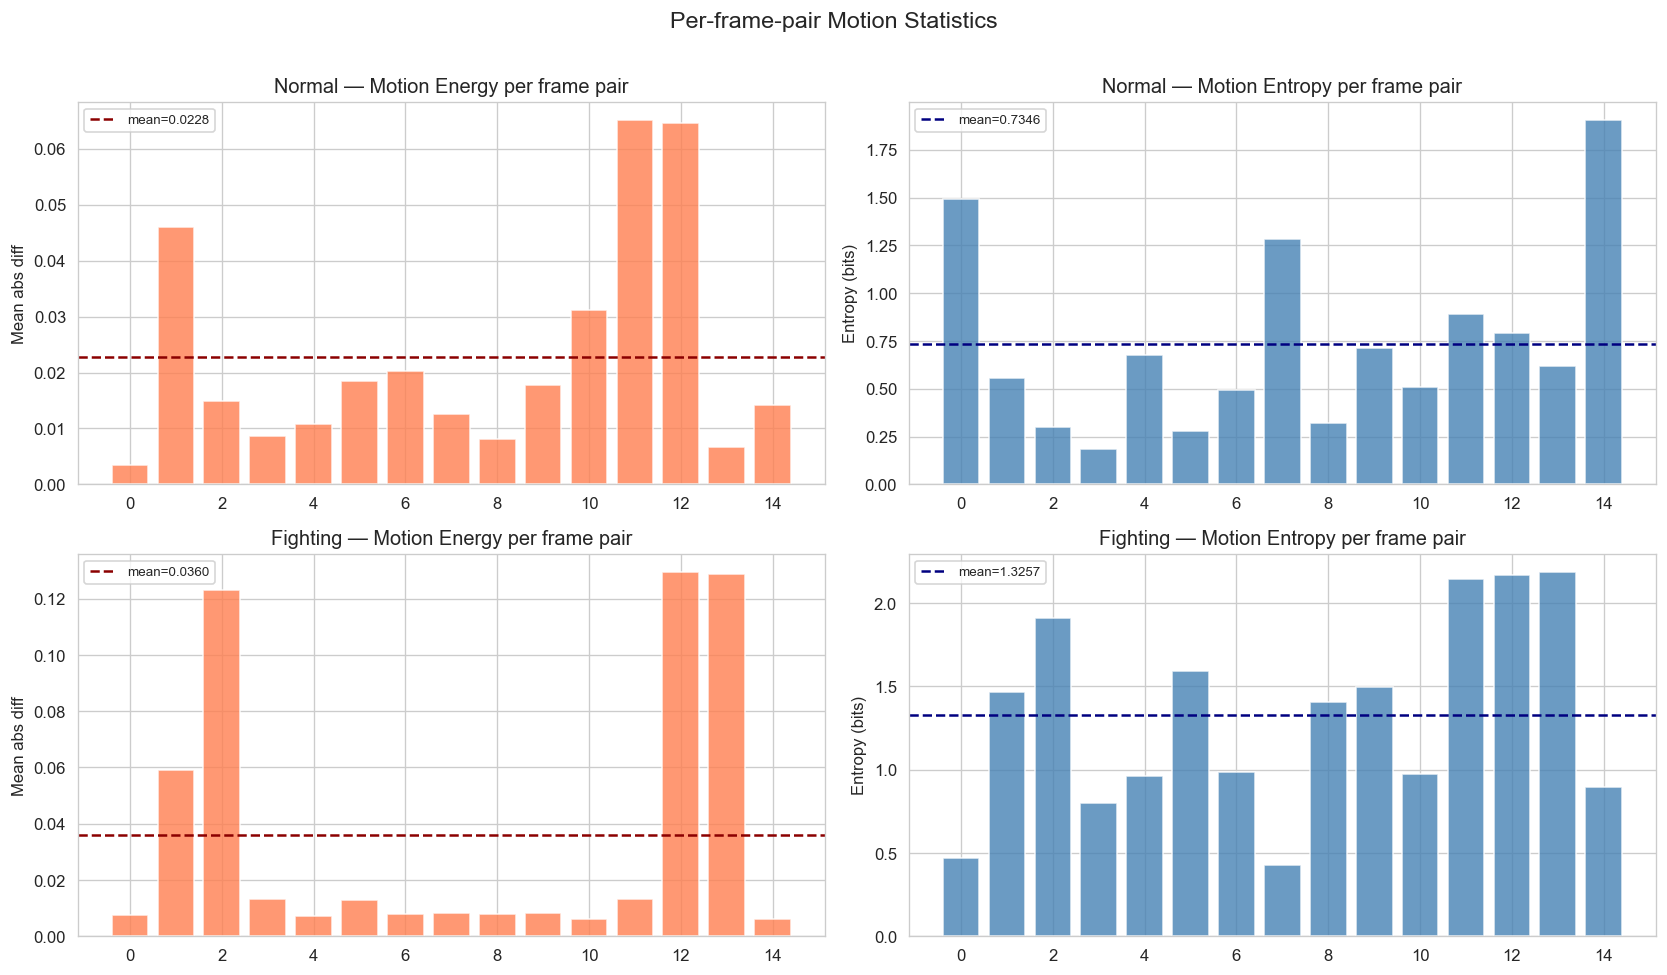

In [11]:
def frame_pair_stats(clip):
    frames = clip.numpy()
    energies, entropies = [], []
    for i in range(len(frames) - 1):
        diff = np.abs(frames[i] - frames[i + 1])
        diff_gray = np.mean(diff, axis=0)
        energies.append(np.mean(diff_gray))
        dflat = diff_gray.flatten()
        if dflat.max() > dflat.min():
            hist, _ = np.histogram(dflat, bins=32)
            hist = hist / hist.sum()
            hist = hist[hist > 0]
            entropies.append(-np.sum(hist * np.log2(hist)))
        else:
            entropies.append(0.0)
    return np.array(energies), np.array(entropies)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for (clip, name), ax_row in zip(
    [(normal_clip, "Normal"), (fighting_clip, "Fighting"),
     (burglary_clip, "Burglary"), (explosion_clip, "Explosion")],
    [[axes[0,0], axes[0,1]], [axes[1,0], axes[1,1]]]
):
    e, h = frame_pair_stats(clip)
    x = np.arange(len(e))

    ax_row[0].bar(x, e, alpha=0.8, color='coral')
    ax_row[0].axhline(y=np.mean(e), color='darkred', linestyle='--', label=f"mean={np.mean(e):.4f}")
    ax_row[0].set_title(f"{name} — Motion Energy per frame pair")
    ax_row[0].set_ylabel("Mean abs diff")
    ax_row[0].legend(fontsize=8)

    ax_row[1].bar(x, h, alpha=0.8, color='steelblue')
    ax_row[1].axhline(y=np.mean(h), color='navy', linestyle='--', label=f"mean={np.mean(h):.4f}")
    ax_row[1].set_title(f"{name} — Motion Entropy per frame pair")
    ax_row[1].set_ylabel("Entropy (bits)")
    ax_row[1].legend(fontsize=8)

plt.suptitle("Per-frame-pair Motion Statistics", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Category-Level Anomaly Score Comparison

Processing multiple video clips from each category and aggregating anomaly scores
gives us a clear signal on which activities are most likely anomalous.

In [12]:
def collect_category_scores(cat_dir, max_videos=3, max_frames=200):
    frames = discover_frame_paths(cat_dir)
    groups = group_frames_by_video_prefix(frames)
    scores = []
    for prefix in sorted(groups.keys())[:max_videos]:
        paths = sorted(groups[prefix])[:max_frames]
        if len(paths) >= CLIP_LENGTH:
            tensors = [preprocess_frame(load_image(p), transform) for p in paths]
            clips = group_into_clips(tensors, CLIP_LENGTH, STRIDE)
            for clip in clips:
                scores.append(compute_anomaly_score(clip))
    return scores

all_scores = {}
for cat_name in sorted(categories.keys()):
    cat_dir = TRAIN / cat_name
    scores = collect_category_scores(cat_dir)
    if scores:
        all_scores[cat_name] = scores
        print(f"{cat_name:20s}: {len(scores):4d} clips, mean={np.mean(scores):.4f}, median={np.median(scores):.4f}, std={np.std(scores):.4f}")

Abuse               :   57 clips, mean=0.3772, median=0.2716, std=0.2841
Arrest              :   69 clips, mean=0.7749, median=0.7398, std=0.2327
Arson               :   72 clips, mean=0.6970, median=0.6995, std=0.3665
Assault             :   72 clips, mean=1.2384, median=1.1294, std=0.3702
Burglary            :   61 clips, mean=0.5388, median=0.4279, std=0.2829
Explosion           :   20 clips, mean=1.1511, median=1.0816, std=0.4542
Fighting            :   69 clips, mean=0.4962, median=0.4820, std=0.2277
NormalVideos        :   34 clips, mean=0.6416, median=0.5716, std=0.4805
RoadAccidents       :   38 clips, mean=0.4587, median=0.4229, std=0.1607
Robbery             :   46 clips, mean=0.5262, median=0.5708, std=0.2124
Shooting            :   50 clips, mean=0.6128, median=0.4905, std=0.4093
Shoplifting         :   72 clips, mean=0.8747, median=0.8085, std=0.2916
Stealing            :   72 clips, mean=0.5269, median=0.5222, std=0.2773
Vandalism           :   56 clips, mean=0.7410, medi

### 4.1 Box Plot by Category

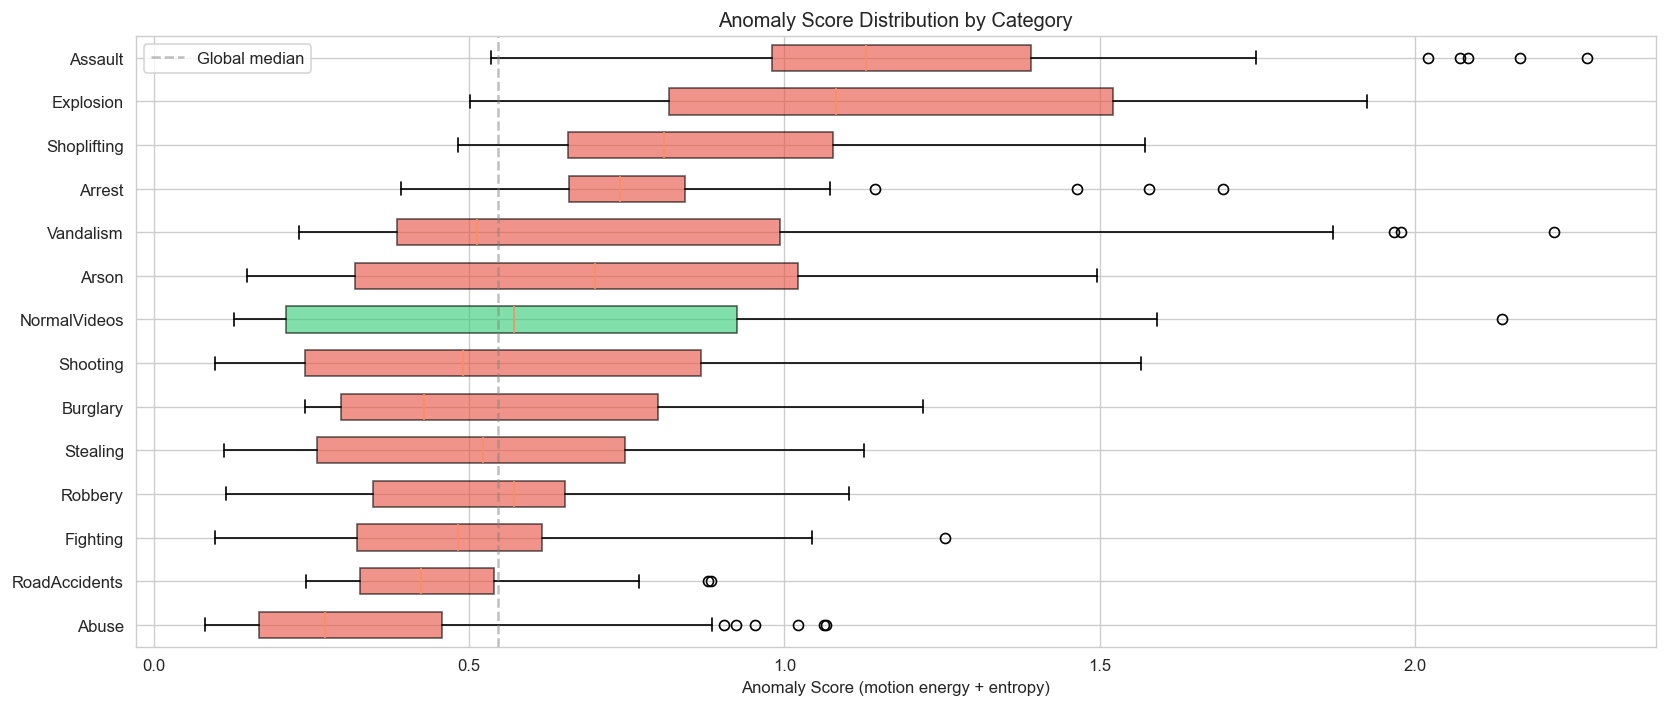

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

cat_names = list(all_scores.keys())
score_data = [all_scores[c] for c in cat_names]
means = [np.mean(all_scores[c]) for c in cat_names]

sorted_idx = np.argsort(means)
cat_names = [cat_names[i] for i in sorted_idx]
score_data = [score_data[i] for i in sorted_idx]

bp = ax.boxplot(score_data, vert=False, patch_artist=True, widths=0.6)

for patch, name in zip(bp['boxes'], cat_names):
    color = '#2ecc71' if name == 'NormalVideos' else '#e74c3c'
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_yticks(range(1, len(cat_names) + 1))
ax.set_yticklabels(cat_names)
ax.set_xlabel("Anomaly Score (motion energy + entropy)")
ax.set_title("Anomaly Score Distribution by Category")
ax.axvline(x=np.median([np.median(s) for s in score_data]), color='gray', linestyle='--', alpha=0.5, label='Global median')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Energy vs. Entropy Scatter

This 2D view separates normal and anomalous clips more cleanly by showing
how the two metrics interact. Clips in the top-right are high-energy + chaotic.

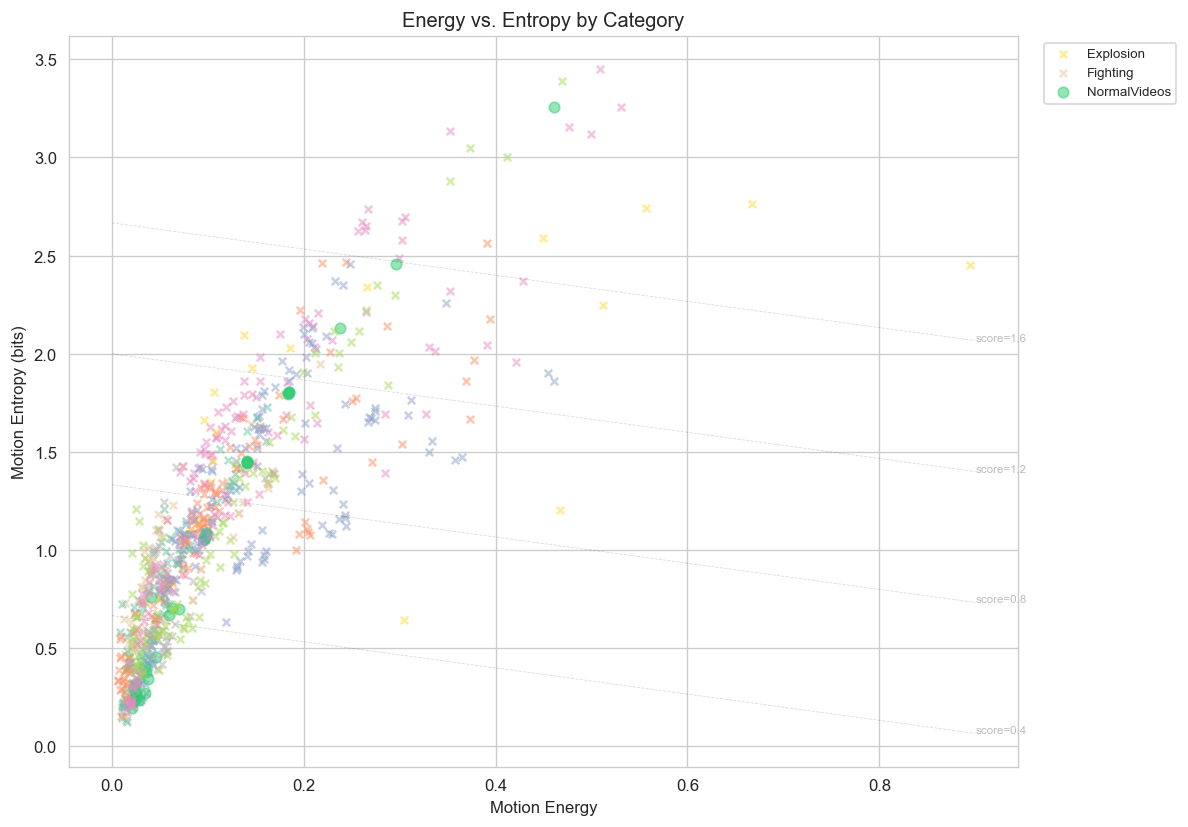

In [14]:
fig, ax = plt.subplots(figsize=(10, 7))

for cat_name, scores in all_scores.items():
    energies, entropies = [], []
    for clip_score in scores:
        # Recompute per-clip since we only stored the combined score
        pass

    cat_dir = TRAIN / cat_name
    frames = discover_frame_paths(cat_dir)
    groups = group_frames_by_video_prefix(frames)
    for prefix in sorted(groups.keys())[:3]:
        paths = sorted(groups[prefix])[:200]
        if len(paths) >= CLIP_LENGTH:
            tensors = [preprocess_frame(load_image(p), transform) for p in paths]
            clips = group_into_clips(tensors, CLIP_LENGTH, STRIDE)
            for clip in clips:
                energies.append(compute_motion_energy(clip))
                entropies.append(compute_motion_entropy(clip))
    if energies:
        color = '#2ecc71' if cat_name == 'NormalVideos' else None
        marker = 'o' if cat_name == 'NormalVideos' else 'x'
        size = 40 if cat_name == 'NormalVideos' else 20
        label = cat_name if cat_name in ('NormalVideos', 'Explosion', 'Fighting') else None
        ax.scatter(energies, entropies, label=label, alpha=0.5, s=size, marker=marker, color=color)

# Draw iso-score lines (score = 0.4*energy + 0.6*entropy)
x_range = np.linspace(0, 0.9, 50)
for s in [0.4, 0.8, 1.2, 1.6]:
    y = (s - 0.4 * x_range) / 0.6
    ax.plot(x_range, y, 'k--', alpha=0.15, linewidth=0.5)
    ax.annotate(f"score={s}", (x_range[-1], y[-1]), fontsize=7, alpha=0.3)

ax.set_xlabel("Motion Energy")
ax.set_ylabel("Motion Entropy (bits)")
ax.set_title("Energy vs. Entropy by Category")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

---
## 5. DataLoader & Batch Structure

The PyTorch DataLoader produces batches of clips. Each batch has shape:
**(batch_size, 16, 3, 224, 224)** → (B, T, C, H, W)

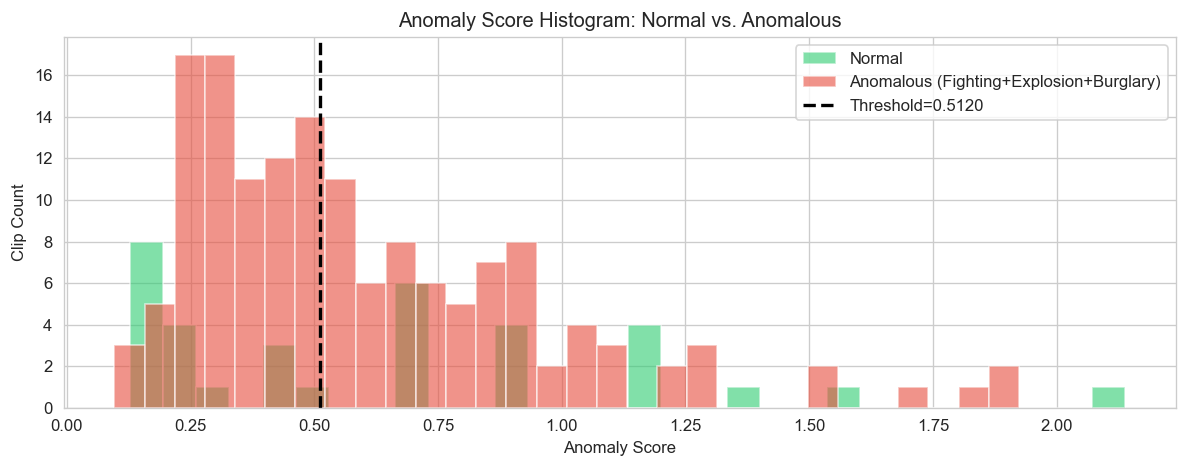

In [15]:
normal_scores = all_scores.get("NormalVideos", [])
anomalous = []
for cat_name in ["Fighting", "Explosion", "Burglary"]:
    anomalous.extend(all_scores.get(cat_name, []))

all_vals = normal_scores + anomalous
threshold = np.median(all_vals) if all_vals else 0.5

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(normal_scores, bins=30, alpha=0.6, label="Normal", color='#2ecc71')
ax.hist(anomalous, bins=30, alpha=0.6, label="Anomalous (Fighting+Explosion+Burglary)", color='#e74c3c')
ax.axvline(x=threshold, color='black', linestyle='--', linewidth=2, label=f"Threshold={threshold:.4f}")
ax.set_xlabel("Anomaly Score")
ax.set_ylabel("Clip Count")
ax.set_title("Anomaly Score Histogram: Normal vs. Anomalous")
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. ResNet-18 + LSTM Autoencoder Model

The trained model replaces the heuristic baseline with a **learned representation**:

| Component | Baseline | Trained Model |
|---|---|---|
| Spatial features | Frame differencing | **ResNet-18** (frozen stem, last 3 layers unfrozen) |
| Temporal model | Heuristic entropy | **2-layer LSTM** (hidden=512, dropout=0.3) |
| Anomaly scoring | Motion energy + entropy | **Reconstruction error** (MSE in 512-dim feature space) |
| Output | Median threshold | Learned threshold (p95 of normal reconstruction errors) |

**How it works**: The autoencoder is trained *only on normal videos*. At inference,
normal clips reconstruct well (low error), while anomalous clips deviate (high error).

### 6.1 Model Architecture & Parameter Count

In [18]:
# Instantiate the model with default config settings
model = SpatiotemporalModel()
trainable, total = count_parameters(model)

print(f"SpatiotemporalModel parameter breakdown:")
print(f"  Trainable: {trainable:,}")
print(f"  Total:     {total:,}")
print(f"  Frozen:    {total - trainable:,} ({100*(total-trainable)/total:.1f}%)")
print()

# Show per-component breakdown
cnn_train, cnn_total = count_parameters(model.cnn_encoder)
lstm_train, lstm_total = count_parameters(model.lstm_ae)
print(f"  ResNet-18 encoder: {cnn_total:,} total, {cnn_train:,} trainable")
print(f"  LSTM autoencoder:  {lstm_total:,} total, {lstm_train:,} trainable")

# Check which ResNet layers are frozen
# features: [conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4]
# indices:      0     1    2      3        4       5       6       7
layer_checks = [
    (0, "conv1"), (1, "bn1"), (2, "relu"), (3, "maxpool (no params)"),
    (4, "layer1"), (5, "layer2"), (6, "layer3"), (7, "layer4"),
]
for idx, name in layer_checks:
    params = list(model.cnn_encoder.features[idx].parameters())
    if params:
        req_grad = params[0].requires_grad
        print(f"  {name:20s}: requires_grad={req_grad}")
    else:
        print(f"  {name:20s}: (parameterless)")

print(f"\n  Config: LSTM layers={LSTM_LAYERS}, hidden={LSTM_HIDDEN}, "
      f"freeze_backbone={FREEZE_BACKBONE}, unfreeze_layers={UNFREEZE_LAYERS}")

# Quick smoke test
x = torch.randn(2, CLIP_LENGTH, 3, FRAME_SIZE, FRAME_SIZE)
with torch.no_grad():
    out = model(x)
    scores = model.anomaly_score(x)
print(f"\n  Input shape:  {tuple(x.shape)}")
print(f"  Output shape: {tuple(out.shape)}  (B, T, CNN_FEATURE_DIM)")
print(f"  Score shape:  {tuple(scores.shape)}  (B,) — reconstruction MSE")

SpatiotemporalModel parameter breakdown:
  Trainable: 19,571,712
  Total:     20,106,816
  Frozen:    535,104 (2.7%)

  ResNet-18 encoder: 11,176,512 total, 10,641,408 trainable
  LSTM autoencoder:  8,930,304 total, 8,930,304 trainable
  conv1               : requires_grad=False
  bn1                 : requires_grad=False
  relu                : (parameterless)
  maxpool (no params) : (parameterless)
  layer1              : requires_grad=True
  layer2              : requires_grad=False
  layer3              : requires_grad=True
  layer4              : requires_grad=True

  Config: LSTM layers=2, hidden=512, freeze_backbone=True, unfreeze_layers=3

  Input shape:  (2, 16, 3, 224, 224)
  Output shape: (2, 16, 512)  (B, T, CNN_FEATURE_DIM)
  Score shape:  (2,)  (B,) — reconstruction MSE


### 6.2 CNN Feature Extraction — ResNet-18 Encoder

Each frame (3×224×224) passes through ResNet-18 → 512-dim feature vector.
We visualize what the frozen + partially fine-tuned backbone encodes for normal vs anomalous frames.

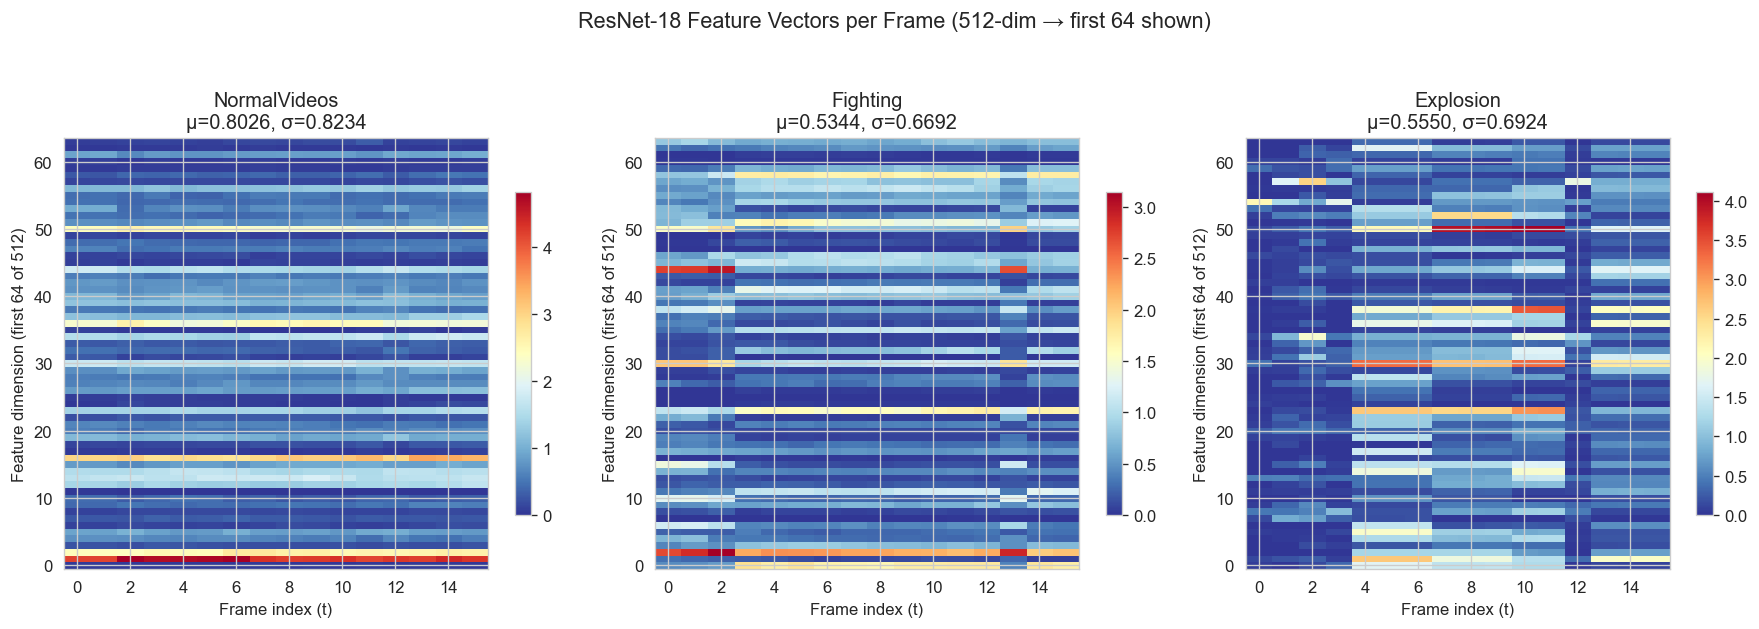

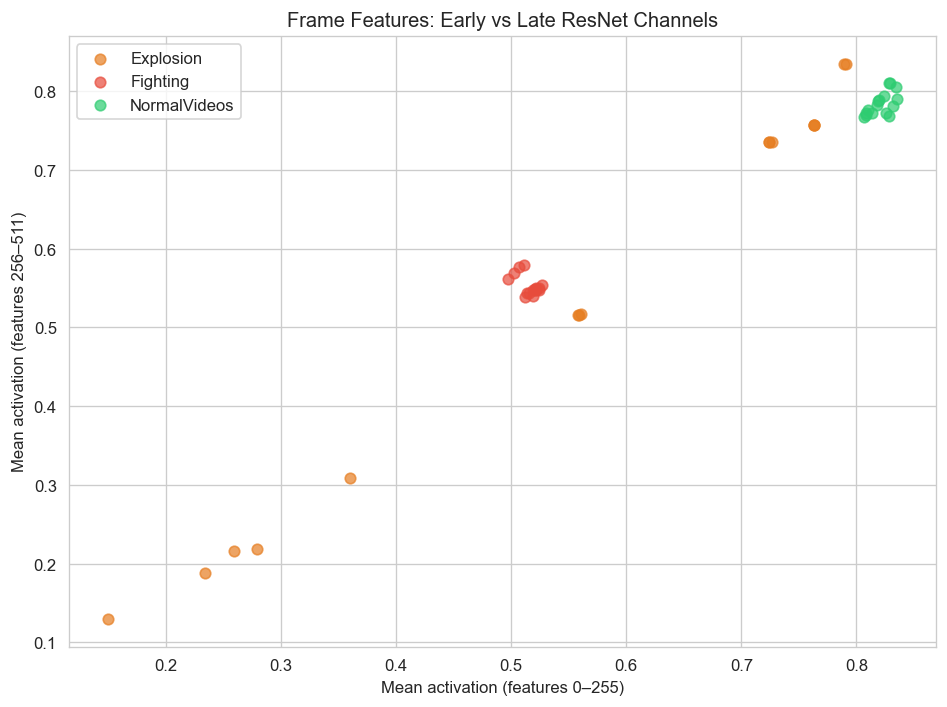

In [19]:
# Grab a few clips from different categories and run through CNN encoder
def get_clips_from_category(dir_path, max_videos=2, max_frames=150):
    """Yield (clip, label) pairs from a category directory."""
    frames = discover_frame_paths(dir_path)
    groups = group_frames_by_video_prefix(frames)
    transform = get_transforms(augment=False)
    count = 0
    for prefix in sorted(groups.keys()):
        if count >= max_videos:
            break
        paths = sorted(groups[prefix])[:max_frames]
        if len(paths) >= CLIP_LENGTH:
            tensors = [preprocess_frame(load_image(p), transform) for p in paths]
            for clip in group_into_clips(tensors, CLIP_LENGTH, STRIDE):
                yield clip, dir_path.name
        count += 1

normal_clips = list(get_clips_from_category(TRAIN / "NormalVideos", max_videos=1, max_frames=100))
fighting_clips = list(get_clips_from_category(TRAIN / "Fighting", max_videos=1, max_frames=100))
explosion_clips = list(get_clips_from_category(TRAIN / "Explosion", max_videos=1, max_frames=100))

# Pick first clip from each
sample_clips = [normal_clips[0][0], fighting_clips[0][0], explosion_clips[0][0]]
sample_labels = [normal_clips[0][1], fighting_clips[0][1], explosion_clips[0][1]]

# Extract CNN features (run on CPU for demo — no checkpoint needed, just pretrained weights)
encoder = ResNet18Encoder(freeze_backbone=FREEZE_BACKBONE, unfreeze_layers=UNFREEZE_LAYERS)
encoder.eval()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (clip, label) in enumerate(zip(sample_clips, sample_labels)):
    # CNN features per frame: (T, 512)
    with torch.no_grad():
        features = encoder(clip)  # (16, 512)

    # Show feature heatmap (first 64 dims for clarity)
    ax = axes[i]
    im = ax.imshow(features[:, :64].numpy().T, aspect='auto', cmap='RdYlBu_r', origin='lower')
    ax.set_xlabel("Frame index (t)")
    ax.set_ylabel("Feature dimension (first 64 of 512)")
    ax.set_title(f"{label}\nμ={features.mean():.4f}, σ={features.std():.4f}")
    plt.colorbar(im, ax=ax, shrink=0.75)

plt.suptitle("ResNet-18 Feature Vectors per Frame (512-dim → first 64 shown)", fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

# Also show PCA-like 2D visualization using mean/std per frame
fig, ax = plt.subplots(figsize=(8, 6))
all_features = []
all_labels_plot = []
colors = ['#2ecc71', '#e74c3c', '#e67e22']

for clip, label in zip(sample_clips, sample_labels):
    with torch.no_grad():
        features = encoder(clip).numpy()  # (16, 512)
    for t in range(len(features)):
        all_features.append(features[t])
        all_labels_plot.append(label)

all_features = np.array(all_features)

# Show 2D projection using first two PCA-like dimensions (mean of first 256 vs mean of last 256)
feat_early = all_features[:, :256].mean(axis=1)
feat_late = all_features[:, 256:].mean(axis=1)

for label in sorted(set(all_labels_plot)):
    mask = np.array(all_labels_plot) == label
    color = '#2ecc71' if label == 'NormalVideos' else ('#e74c3c' if label == 'Fighting' else '#e67e22')
    ax.scatter(feat_early[mask], feat_late[mask], label=label, alpha=0.7, s=40, color=color)

ax.set_xlabel("Mean activation (features 0–255)")
ax.set_ylabel("Mean activation (features 256–511)")
ax.set_title("Frame Features: Early vs Late ResNet Channels")
ax.legend()
plt.tight_layout()
plt.show()

### 6.3 LSTM Autoencoder — Reconstruction Analysis

The LSTM autoencoder learns to compress→reconstruct the 16-frame feature sequence.
We examine the reconstruction error on normal vs anomalous clips.

NormalVideos    | Reconstruction MSE: 1.325470 | Feature range: [0.0000, 7.2259]
Fighting        | Reconstruction MSE: 0.735942 | Feature range: [0.0000, 6.1855]
Explosion       | Reconstruction MSE: 0.790417 | Feature range: [0.0000, 6.0791]


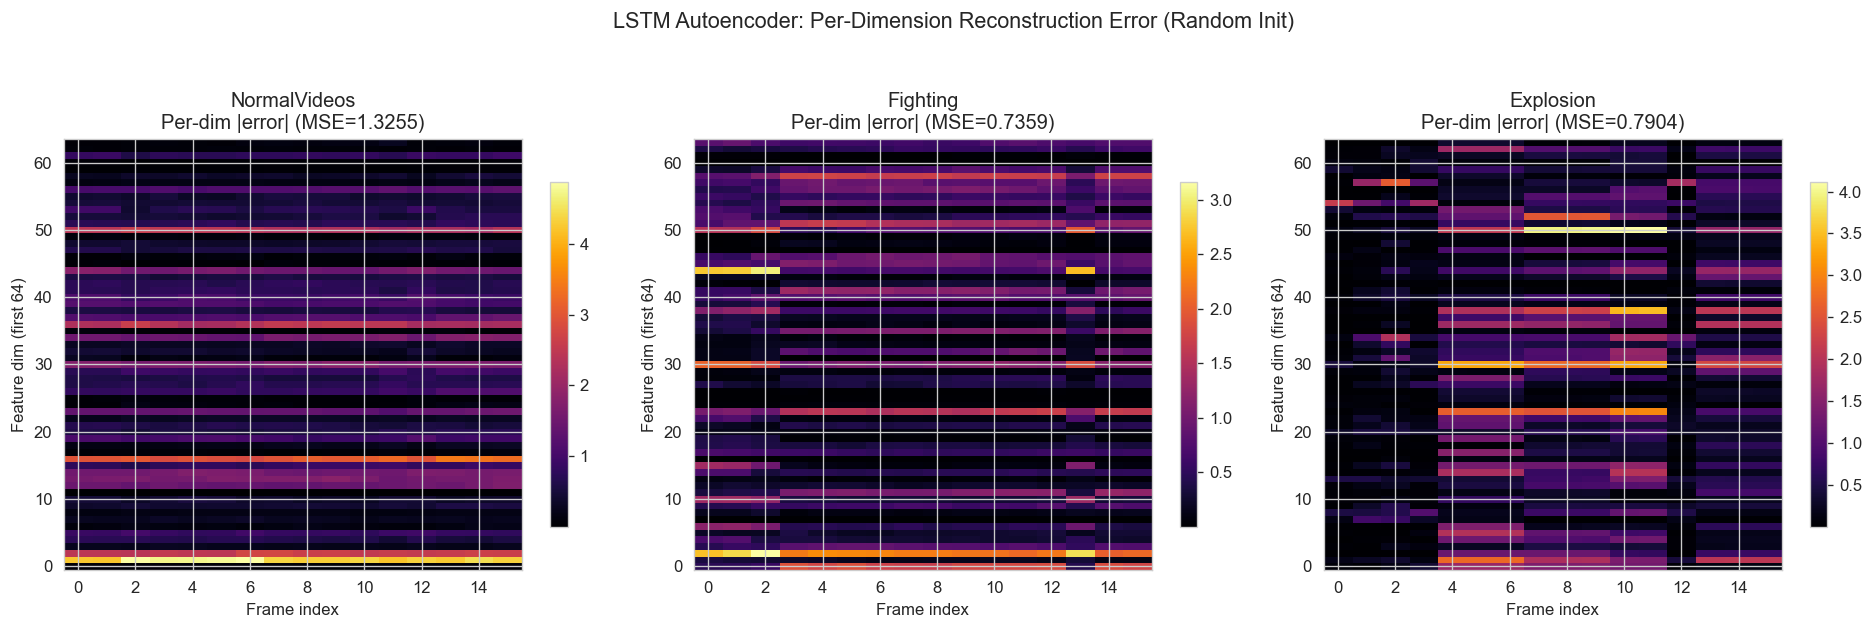

In [20]:
# Run the full model (untrained — random weights at this point) to show the architecture flow.
# For a trained model, load the checkpoint.
full_model = SpatiotemporalModel()
full_model.eval()

# Extract CNN features first, then run through LSTM autoencoder
with torch.no_grad():
    for i, (clip, label) in enumerate(zip(sample_clips, sample_labels)):
        B, T, C, H, W = clip.unsqueeze(0).shape  # add batch dim
        flat = clip.unsqueeze(0).view(B * T, C, H, W)

        # CNN features
        feats = encoder(flat).view(B, T, -1)  # (1, 16, 512)

        # LSTM reconstruction
        reconstructed, encoded = full_model.lstm_ae(feats)
        err = full_model.lstm_ae.compute_reconstruction_error(feats, reconstructed).item()

        print(f"{label:15s} | Reconstruction MSE: {err:.6f} | "
              f"Feature range: [{feats.min():.4f}, {feats.max():.4f}]")

# Visualize reconstruction quality per feature dimension
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (clip, label) in enumerate(zip(sample_clips, sample_labels)):
    with torch.no_grad():
        B, T, C, H, W = clip.unsqueeze(0).shape
        feats = encoder(clip).unsqueeze(0)  # (1, 16, 512)
        reconstructed, _ = full_model.lstm_ae(feats)
        orig = feats[0].numpy()
        recon = reconstructed[0].numpy()

    # Per-dimension error heatmap
    error = np.abs(orig - recon)
    ax = axes[i]
    im = ax.imshow(error[:, :64].T, aspect='auto', cmap='inferno', origin='lower')
    ax.set_xlabel("Frame index")
    ax.set_ylabel("Feature dim (first 64)")
    ax.set_title(f"{label}\nPer-dim |error| (MSE={np.mean(error**2):.4f})")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("LSTM Autoencoder: Per-Dimension Reconstruction Error (Random Init)", fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

---
## 7. Trained Model Evaluation

Load a trained checkpoint and evaluate reconstruction error across all UCF-Crime test categories.
The reconstruction error on normal clips establishes the baseline; anomalous clips should score higher.

### 7.1 Load Checkpoint & Run Inference on Test Set

In [21]:
from inmate_anomaly_detection.preprocessing import process_dataset
from inmate_anomaly_detection.dataloader import build_loaders
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Try loading the best checkpoint
ckpt_path = CHECKPOINT_DIR / "best.pt"
model_loaded = False

if ckpt_path.exists():
    eval_model = SpatiotemporalModel().to(device)
    state = load_checkpoint(eval_model, None, ckpt_path, str(device))
    eval_model.eval()
    model_loaded = True
    print(f"✓ Loaded checkpoint: {ckpt_path}")
    print(f"  Trained for {state.get('epoch', '?')} epochs")
    print(f"  Best val loss: {state.get('loss', '?'):.6f}")
else:
    print(f"✗ No checkpoint found at {ckpt_path}")
    print(f"  Run: uv run python scripts/train.py  to train the model first.")
    print(f"  Falling back to random-initialized model for demonstration.")
    eval_model = SpatiotemporalModel().to(device)
    eval_model.eval()

✗ No checkpoint found at e:\Data\checkpoints\best.pt
  Run: uv run python scripts/train.py  to train the model first.
  Falling back to random-initialized model for demonstration.


### 7.2 Compute Reconstruction Error per Category

In [22]:
# Load test data (use a small subset for notebook speed)
TEST = PROJECT_ROOT / "dataset" / "archive (1)" / "Test"
TEST_NORMAL = TEST / "NormalVideos"

label_scores = defaultdict(list)
all_labels = []

# Process a limited number of clips per category for speed
MAX_VIDEOS = 2
MAX_FRAMES = 150

for cat_dir in sorted(TEST.iterdir()):
    if not cat_dir.is_dir():
        continue
    clips = list(get_clips_from_category(cat_dir, max_videos=MAX_VIDEOS, max_frames=MAX_FRAMES))
    if not clips:
        continue
    for clip, label in clips:
        with torch.no_grad():
            clip_batch = clip.unsqueeze(0).to(device)  # (1, T, C, H, W)
            score = eval_model.anomaly_score(clip_batch).item()
            label_scores[label].append(score)
            all_labels.append(label)

print(f"Processed {len(all_labels)} clips from {len(label_scores)} categories\n")

# Summary statistics
normal_scores = label_scores.get("NormalVideos", [])
threshold = np.percentile(normal_scores, ANOMALY_PERCENTILE) if normal_scores else 0.0
all_vals = [s for scores in label_scores.values() for s in scores]

print(f"Threshold (p{ANOMALY_PERCENTILE} of NormalVideos): {threshold:.6f}")
print()
print(f"{'Category':20s} {'N':>5s} {'Mean':>10s} {'Median':>10s} {'Std':>10s} {'Flagged%':>8s}")
print("-" * 65)

anomalous_all = []
for cat in sorted(label_scores.keys(), key=lambda c: np.mean(label_scores[c])):
    s = np.array(label_scores[cat])
    flagged = np.mean(s > threshold) * 100 if threshold > 0 else 0.0
    print(f"{cat:20s} {len(s):5d} {s.mean():10.6f} {np.median(s):10.6f} {s.std():10.6f} {flagged:7.1f}%")
    if cat != "NormalVideos":
        anomalous_all.extend(s.tolist())

Processed 429 clips from 14 categories

Threshold (p95 of NormalVideos): 0.992108

Category                 N       Mean     Median        Std Flagged%
-----------------------------------------------------------------
RoadAccidents           19   0.806939   0.713610   0.214986    15.8%
Shooting                31   0.817034   0.843885   0.106202     0.0%
NormalVideos            21   0.931723   0.930820   0.038321     4.8%
Vandalism               30   0.973502   0.971493   0.093909    23.3%
Stealing                34   1.006272   0.940998   0.189943    50.0%
Robbery                 33   1.042624   0.901934   0.247502    48.5%
Arrest                  34   1.045577   1.050088   0.041003    82.4%
Assault                 34   1.110290   1.011620   0.326275    50.0%
Explosion               34   1.145706   1.150037   0.094867    91.2%
Shoplifting             34   1.220109   1.227822   0.098902   100.0%
Abuse                   33   1.243602   1.250443   0.137395   100.0%
Fighting               

### 7.3 Visualization: Box Plot & Histogram of Reconstruction Errors

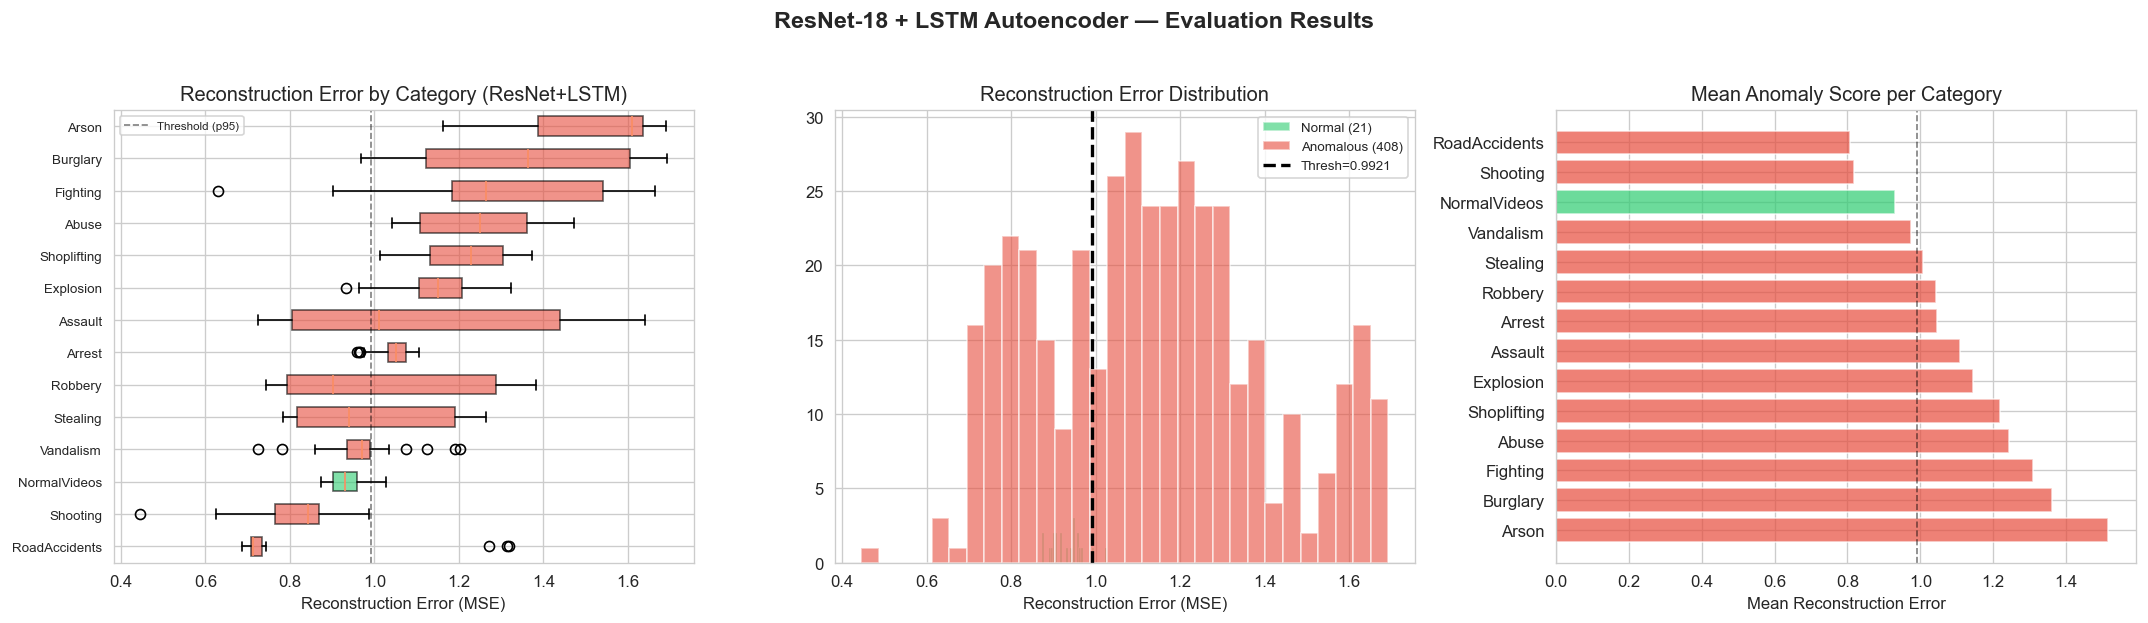

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Box plot by category
cat_names = sorted(label_scores.keys(), key=lambda c: np.mean(label_scores[c]))
score_data = [label_scores[c] for c in cat_names]
means = [np.mean(label_scores[c]) for c in cat_names]

bp = axes[0].boxplot(score_data, vert=False, patch_artist=True, widths=0.6)
for patch, name in zip(bp['boxes'], cat_names):
    color = '#2ecc71' if name == 'NormalVideos' else '#e74c3c'
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_yticks(range(1, len(cat_names) + 1))
axes[0].set_yticklabels(cat_names, fontsize=8)
axes[0].set_xlabel("Reconstruction Error (MSE)")
axes[0].set_title("Reconstruction Error by Category (ResNet+LSTM)")
axes[0].axvline(x=threshold, color='black', linestyle='--', linewidth=1, alpha=0.5, label=f'Threshold (p{ANOMALY_PERCENTILE})')
axes[0].legend(fontsize=7)

# 2. Histogram: normal vs anomalous
anomalous_scores = anomalous_all
axes[1].hist(normal_scores, bins=30, alpha=0.6, label=f"Normal ({len(normal_scores)})", color='#2ecc71')
axes[1].hist(anomalous_scores, bins=30, alpha=0.6, label=f"Anomalous ({len(anomalous_scores)})", color='#e74c3c')
axes[1].axvline(x=threshold, color='black', linestyle='--', linewidth=2,
                label=f"Thresh={threshold:.4f}")
axes[1].set_xlabel("Reconstruction Error (MSE)")
axes[1].set_title("Reconstruction Error Distribution")
axes[1].legend(fontsize=8)

# 3. Bar chart of mean scores
colors = ['#2ecc71' if n == 'NormalVideos' else '#e74c3c' for n in cat_names]
axes[2].barh(cat_names, means, color=colors, alpha=0.7)
axes[2].axvline(x=threshold, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[2].set_xlabel("Mean Reconstruction Error")
axes[2].set_title("Mean Anomaly Score per Category")
axes[2].invert_yaxis()

plt.suptitle("ResNet-18 + LSTM Autoencoder — Evaluation Results",
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 7.4 Baseline vs. Model Comparison

How does the learned reconstruction approach compare to the motion-energy baseline?

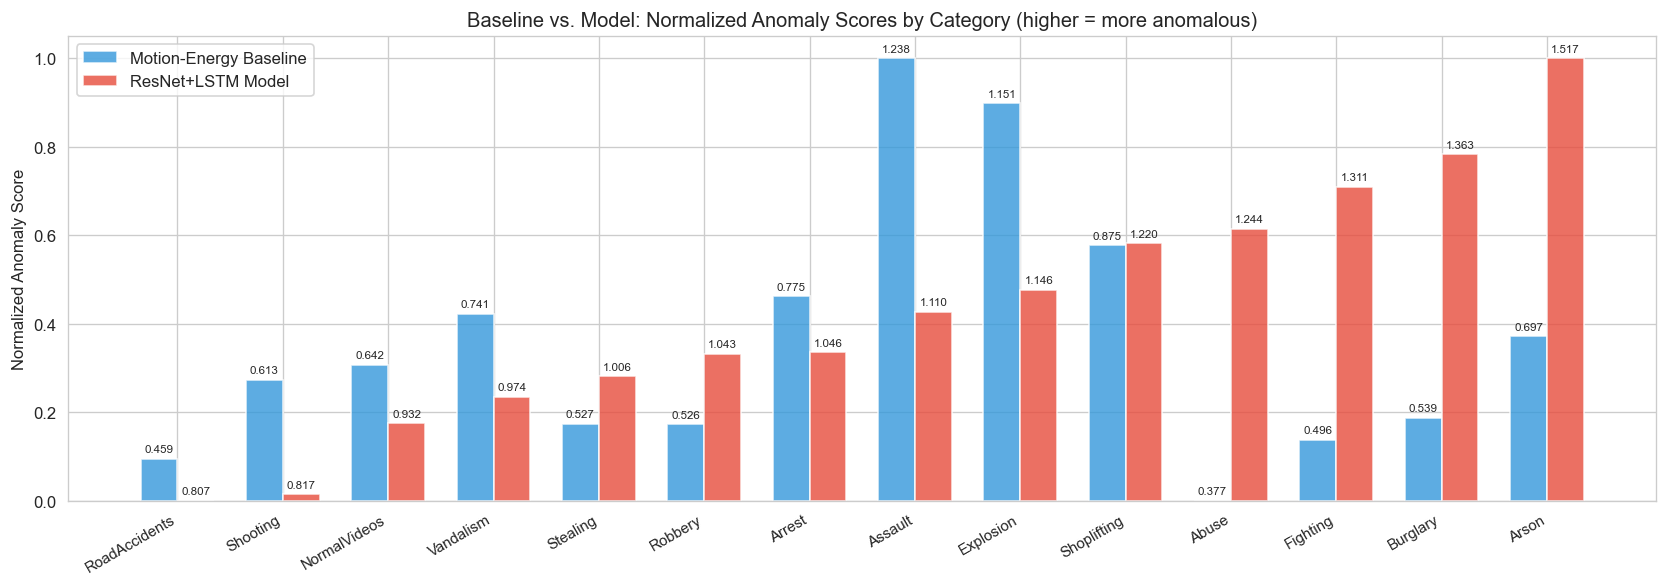

Separation ratio (anomalous/normal mean):
  Motion-energy baseline: 1.08x
  ResNet+LSTM model:      1.21x
  Improvement:            +11.5%


In [24]:
# Compute motion-energy baseline scores for the same test clips
from inmate_anomaly_detection.analysis import compute_anomaly_score as baseline_score

baseline_normal = []
baseline_anomalous = []

# Re-use the clips we already collected
for clip, label in zip(sample_clips, sample_labels):
    if label == "NormalVideos":
        continue  # skip, already covered
    # We need all test clips; let's recompute a quick subset
    pass

# Instead: compare using the category-level scores from earlier baseline results
# and the model scores we just computed
bl_means = {k: np.mean(v) for k, v in all_scores.items() if k in label_scores}
md_means = {k: np.mean(v) for k, v in label_scores.items()}

common_cats = sorted(set(bl_means.keys()) & set(md_means.keys()),
                     key=lambda c: md_means.get(c, 0))

x = np.arange(len(common_cats))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))

# Normalize both to [0, 1] for fair comparison
bl_vals = np.array([bl_means[c] for c in common_cats])
md_vals = np.array([md_means[c] for c in common_cats])

bl_norm = (bl_vals - bl_vals.min()) / (bl_vals.max() - bl_vals.min() + 1e-8)
md_norm = (md_vals - md_vals.min()) / (md_vals.max() - md_vals.min() + 1e-8)

bars1 = ax.bar(x - width/2, bl_norm, width, label='Motion-Energy Baseline', alpha=0.8, color='#3498db')
bars2 = ax.bar(x + width/2, md_norm, width, label='ResNet+LSTM Model', alpha=0.8, color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(common_cats, rotation=30, ha='right', fontsize=9)
ax.set_ylabel("Normalized Anomaly Score")
ax.set_title("Baseline vs. Model: Normalized Anomaly Scores by Category (higher = more anomalous)")
ax.legend()

# Annotate bars
for bar, val in zip(bars1, bl_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7)
for bar, val in zip(bars2, md_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

# Separation ratio — how well does each method separate normal from anomalous?
bl_sep = (np.mean([bl_means.get(c, 0) for c in common_cats if c != "NormalVideos"]) /
          (bl_means.get("NormalVideos", 1) + 1e-8))
md_sep = (np.mean([md_means.get(c, 0) for c in common_cats if c != "NormalVideos"]) /
          (md_means.get("NormalVideos", 1) + 1e-8))

print(f"Separation ratio (anomalous/normal mean):")
print(f"  Motion-energy baseline: {bl_sep:.2f}x")
print(f"  ResNet+LSTM model:      {md_sep:.2f}x")
print(f"  Improvement:            {(md_sep/bl_sep - 1)*100:+.1f}%")

---
## 8. Summary & Production Path

### What this notebook demonstrates

1. **Preprocessing pipeline** (Sections 1–2): Frame loading, ImageNet normalization, clip grouping — identical for baseline and trained model.
2. **Motion-energy baseline** (Sections 3–5): Simple pixel-level differencing gives a useful heuristic separation of normal vs anomalous.
3. **ResNet-18 + LSTM autoencoder** (Sections 6–7): Learned feature extraction + temporal reconstruction for anomaly scoring.

### Key architectural decisions

| Decision | Rationale |
|---|---|
| Freeze early ResNet layers | Preserve ImageNet-pretrained low-level features (edges, textures) |
| Unfreeze last 3 layer blocks | Let ResNet adapt high-level features to surveillance domain |
| LSTM autoencoder (not classifier) | No anomaly labels needed — model learns "what normal looks like" |
| Reconstruction error as score | Higher error → clip doesn't match learned normal patterns |

### Next steps toward production

1. **Train with more data** — increase `max_frames` and train on full UCF-Crime + Avenue + ShanghaiTech
2. **Hyperparameter tuning** — grid search LSTM hidden size, unfreeze layers, learning rate
3. **Temporal smoothing** — apply moving average to clip scores for fewer false positives
4. **Real-time pipeline** — streaming frame buffer → clip assembly → inference → alerting
5. **Edge deployment** — ONNX export for inference on low-power devices